# 05 - Adaptive intervals: one width does not fit all

> "Your price band is the same plus-or-minus USD 265k on a studio flat as on a lakefront
> villa. That is absurd on the first and suicidal on the second. Can the band breathe
> with the house?" — the acquisitions desk, three weeks and two thousand new listings
> after notebook 02 shipped.

The desk has a point, and it is worth restating as the sharper statistical question this
notebook actually answers: *marginal coverage was never the whole ask*. Notebook 02's
guarantee — 90% of listings land inside their band, on average over everything — is real
and we keep it. But the desk prices individual houses, and it wants the band to be narrow
where pricing is easy and wide where pricing is hard, without losing the guarantee. That
is a property of the **nonconformity score** we chose, not of conformal prediction itself,
and this notebook is about choosing better.

What you will learn:

- how to diagnose per-slice miscoverage hiding under a healthy overall coverage number
- why exact per-house coverage is provably impossible, and what the honest substitute is
- repair 1: normalized (studentized) residuals — a second model sets the local scale
- repair 2: conformalized quantile regression (CQR) — models learn the band edges directly
- how to run a bake-off that judges *where* the width goes, not just how much of it there is

Where we are in the series: notebook 04 took a classification detour with Cairn Health;
we are back at Hearthstone with the regression model from notebook 02, and notebook 06
picks up the other complaint — what to do when there is not enough data to split.

## 1. The complaint from the desk

Recall the fifteen-line recipe from notebook 02. We hold out a calibration set, score each
calibration listing by its absolute error, take the corrected quantile `q_hat` of those
scores, and quote `prediction ± q_hat` for every new listing. The guarantee (notebook 03
proved it with the leaderboard argument) is marginal coverage of at least 90%.

Look at what that construction does geometrically: the *same* `q_hat` is added to and
subtracted from every prediction. One number, every house. The band has exactly constant
width by construction — not approximately, exactly. Nothing about the guarantee forced
that; it came from scoring every listing with the same yardstick, absolute dollars of
error.

Meanwhile the simulator's own docstring has been warning us since notebook 01: "two 60 m2
flats sell for nearly the same price, two 300 m2 villas do not." The noise in log-price
grows with size, so in dollar terms big homes are *much* noisier than small ones. This is
**heteroskedasticity**: noise whose size depends on the input. Our model's errors are not
the same size everywhere — but our band pretends they are. The data science team knew this
from the docstring; the desk found out in production.

Let us rebuild the notebook 02 interval and catch the problem red-handed.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

# Series palette: blue = data, green = good/covered, amber = calibration,
# red = bad/miscovered/naive, gray = reference, purple = alternative method.
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

alpha = 0.10  # the series-wide miscoverage budget: we target 90% coverage

In [2]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]

def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    What the simulator bakes in (and what we will test against later):
    - Price depends nonlinearly on size, age, distance to the center, and condition.
    - Noise is larger for bigger homes: two 60 m2 flats sell for nearly the same
      price, two 300 m2 villas do not. This heteroskedasticity is deliberate.
    - 'riverton' and 'eastvale' differ ONLY in the mix of homes on the market
      (newer, bigger, farther out in eastvale), NOT in how features map to price.
      In the language of notebook 07: pure covariate shift, identical P(price | features).

    Returns X (n x 4 array: size_m2, age_years, dist_center_km, condition_1to5)
    and y (price in thousands of dollars).
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=6.0, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=12.0, size=n)
    else:
        raise ValueError(f"Unknown region: {region}")
    condition = rng.integers(1, 6, size=n).astype(float)
    log_price = (
        10.0
        + 0.70 * np.log(size)
        - 0.004 * age
        - 0.035 * dist
        + 0.05 * condition
    )
    noise_sd = 0.10 + 0.0008 * size  # bigger homes, noisier prices - on purpose
    log_price = log_price + rng.normal(0.0, noise_sd)
    X = np.column_stack([size, age, dist, condition])
    return X, np.exp(log_price) / 1000.0

X, y = simulate_hearthstone_listings(6000, seed=RANDOM_SEED)

We split the 6,000 riverton listings three ways as usual: 3,000 to train the pricing
model, 1,500 to calibrate, 1,500 held back as a test set to audit coverage. And because
this is the third time the series builds this interval, we allow ourselves exactly one
small function: `corrected_quantile`, the boring-but-load-bearing line that every method
in this notebook will share. It carries the field guide §1 assertion with it, so we can
never again ask for a quantile the calibration set cannot honestly deliver.

In [3]:
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=3000, random_state=RANDOM_SEED
)
X_calib, X_test, y_calib, y_test = train_test_split(
    X_rest, y_rest, test_size=1500, random_state=RANDOM_SEED
)

model = GradientBoostingRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)


def corrected_quantile(scores, alpha):
    """The ceil((n+1)(1-alpha))/n empirical quantile of calibration scores.

    The one line of statistics every conformal method shares. The +1 reserves
    a seat in the ranking for the not-yet-seen test listing (notebook 03), and
    method="higher" refuses to interpolate below the honest threshold.
    """
    n = len(scores)
    q_level = math.ceil((n + 1) * (1 - alpha)) / n
    assert q_level <= 1.0, "Calibration set too small for this alpha - the honest interval is infinite (field guide S1)"
    q_hat = np.quantile(scores, q_level, method="higher")
    return q_hat


# Notebook 02's recipe, third appearance: score = absolute pricing error.
mu_calib = model.predict(X_calib)
scores_const = np.abs(y_calib - mu_calib)
q_const = corrected_quantile(scores_const, alpha)

mu_test = model.predict(X_test)
lo_const, hi_const = mu_test - q_const, mu_test + q_const
covered_const = (y_test >= lo_const) & (y_test <= hi_const)

print(f"split: {len(y_train):,} train / {len(y_calib):,} calibration / {len(y_test):,} test")
print(f"median listing price: {np.median(y):.0f} thousand dollars")
print(f"q_hat = {q_const:.1f} -> every interval is prediction +/- {q_const:.0f} thousand dollars")
print(f"overall test coverage: {covered_const.mean():.3f} (target {1 - alpha:.2f})")
print(f"interval width: {np.mean(hi_const - lo_const):.0f} thousand dollars, identical for every listing")

split: 3,000 train / 1,500 calibration / 1,500 test
median listing price: 592 thousand dollars
q_hat = 264.7 -> every interval is prediction +/- 265 thousand dollars
overall test coverage: 0.903 (target 0.90)
interval width: 529 thousand dollars, identical for every listing


Empirical coverage lands at 0.903 on 1,500 test listings — within Monte Carlo noise of
the 0.90 target (two standard errors here is about ±0.015). The machinery works exactly
as advertised. One continuity note before the complaint: notebook 02 shipped ±USD 251k,
calibrated on last quarter's 4,000-listing book. This quarter's 6,000 listings and a
fresh split recalibrate `q_hat` to 264.7 — same recipe, more data, slightly different
number — and the ±USD 265k the desk is quoting is that current production band, not
notebook 02's exact artifact. Now read the last line again: the interval is
`prediction ± 265`, a
USD 529k-wide band stapled onto every home in riverton, where the median listing is worth
USD 592k. The same band on a USD 300k flat and on a USD 2m villa. The guarantee is healthy;
the *shape* is wrong. And note what 0.903 does not mean: it does not mean each individual
house has a 90% chance of landing in its band. It is a batting average over the whole
market — which is exactly the loophole the desk is about to fall through.

## 2. The diagnosis: coverage by slice

The guarantee we have is **marginal coverage** (notebook 03): averaged over all listings,
at least 90% land inside their band. What the desk implicitly wants is **conditional
coverage** (notebook 03 again): 90% *for each kind of house* — small ones, big ones, old
ones, every slice. These are very different promises, and the gap between them is where
the complaint lives (field guide §3: marginal is not conditional).

The audit is cheap: slice the test set by home size and compute coverage per slice. If
the band were adapting properly, every slice would sit near 0.90. Let us look. We will
reuse this little report for every method in the notebook, so it too earns a function.

In [4]:
size_bin_test = pd.cut(
    X_test[:, 0],
    bins=[0, 100, 200, np.inf],
    labels=["small (<100 m2)", "mid (100-200 m2)", "large (>200 m2)"],
)


def slice_report(lo, hi):
    """Coverage and average width on the test set, sliced by home size."""
    per_listing = pd.DataFrame({
        "size_bin": size_bin_test,
        "covered": (y_test >= lo) & (y_test <= hi),
        "width": hi - lo,
    })
    return per_listing.groupby("size_bin", observed=True).agg(
        listings=("covered", "size"),
        coverage=("covered", "mean"),
        avg_width=("width", "mean"),
    )


slice_report(lo_const, hi_const).round(3)

,listings,coverage,avg_width
size_bin,,,
small (<100 m2),217,0.995,529.456
mid (100-200 m2),1049,0.929,529.456
large (>200 m2),234,0.701,529.456


There it is. The healthy 0.903 overall decomposes into 0.995 on small homes, 0.929 on
mid-sized homes, and 0.701 on large ones. On the 234 large test homes we miss 70 — the
desk eats a surprise on nearly one villa in three, precisely the segment where a surprise
costs the most. Meanwhile on small flats we cover 99.5% of the time, which is not a
virtue: it means the band is roughly twice as wide as those homes need, so the desk is
quoting comically hedged offers on the easiest properties in the market.

One printout above deserves a careful reading: the `avg_width` column is 529.456 in every
row. That is not a rendering glitch; it is the definition of the method. The overall
average of 0.995, 0.929 and 0.701 (weighted by bin counts) is still 0.903, so the marginal
guarantee never broke — it just let the easy slice subsidize the hard one. Nothing in the
theorem forbids that, and no bug in our code caused it.

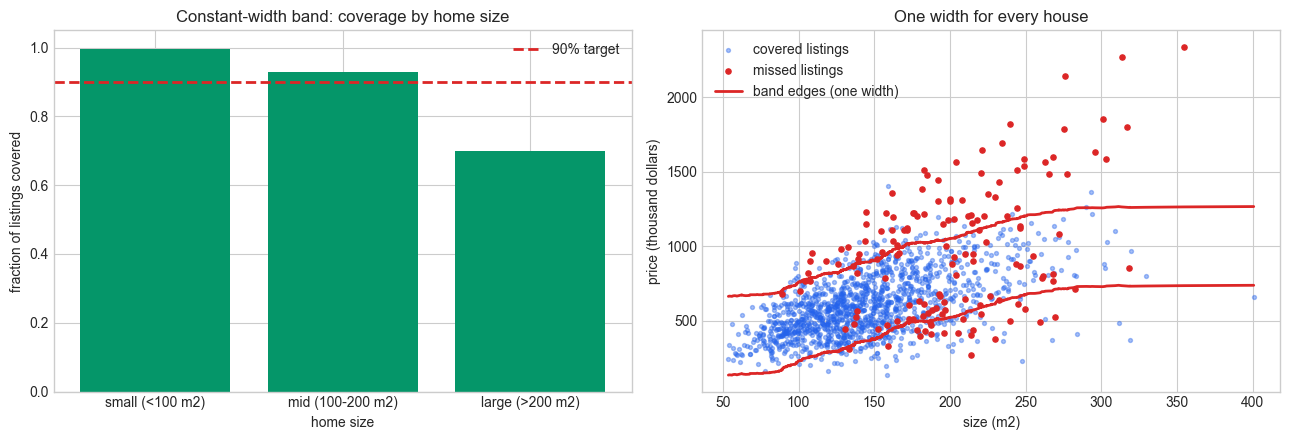

In [5]:
report_const = slice_report(lo_const, hi_const)

# For plotting band edges against size we sort test listings by size and take a
# rolling median - the other three features make per-listing edges a cloud, and
# the rolling median turns that cloud into a readable curve.
order = np.argsort(X_test[:, 0])
size_sorted = X_test[order, 0]


def smooth_by_size(values, window=201):
    """Rolling median of per-listing values along the size axis, for band-edge curves."""
    return pd.Series(values[order]).rolling(window, center=True, min_periods=50).median().to_numpy()


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(report_const.index.astype(str), report_const["coverage"], color=GREEN)
axes[0].axhline(1 - alpha, color=RED, linestyle="--", linewidth=2, label="90% target")
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("Constant-width band: coverage by home size")
axes[0].set_xlabel("home size")
axes[0].set_ylabel("fraction of listings covered")
axes[0].legend()

axes[1].scatter(X_test[covered_const, 0], y_test[covered_const], s=8, alpha=0.4,
                color=BLUE, label="covered listings")
axes[1].scatter(X_test[~covered_const, 0], y_test[~covered_const], s=14,
                color=RED, label="missed listings")
smooth_mu = smooth_by_size(mu_test)
axes[1].plot(size_sorted, smooth_mu - q_const, color=RED, linewidth=2, label="band edges (one width)")
axes[1].plot(size_sorted, smooth_mu + q_const, color=RED, linewidth=2)
axes[1].set_title("One width for every house")
axes[1].set_xlabel("size (m2)")
axes[1].set_ylabel("price (thousand dollars)")
axes[1].legend()

plt.tight_layout()
plt.show()

The right panel is the whole complaint in one picture. On the left of the plot the scatter
of prices is a tight ribbon and the red band edges float well outside it — fat, wasted
width. Past 200 m2 the scatter fans out into a funnel and spills over both edges — the red
missed listings pile up exactly where the money is largest. (One reading note: the drawn
edges follow the *typical* home at each size, since each listing's own band is centered on
its own prediction, which also reacts to age, distance and condition. That is why a few
red dots can sit between the drawn curves — they missed their own band, not the average
one.) The left panel says the same
thing in numbers: only the middle bar sits near the red target line, and the marginal
average is propped up by the overcovered small-home bar. Note that the miss pattern is not
random scatter; it is systematic and it was predictable from the residuals alone — which
means we could and should have printed this table *before* the desk did.

## 3. Grim news, then a loophole

The obvious next wish: a method with a per-house guarantee — 90% at every single `x`. Here
the theory says something blunt. Lei and Wasserman (2014) proved that no distribution-free
method can promise 90% coverage at every individual input without producing infinite
bands. Not "we have not found one yet" — provably impossible. The intuition: at an exact
feature combination you will essentially never see twice, the data contains no information
about how prices behave *right there*, so a method that guarantees coverage there against
every possible world can only do it by hedging infinitely. Honesty at a point you have
never visited costs everything.

So we cannot have conditional coverage exactly. The loophole: nothing stops the *shape*
of the band from tracking difficulty. The guarantee comes from the rank argument of
notebook 03, and that argument never cared what the score measures — any score gives the
same marginal coverage. If we score listings in units that already account for local
difficulty, the corrected quantile hands back a band that is wide where pricing is wild
and narrow where it is calm, and per-slice coverage lands *close* to 90% everywhere even
though it is guaranteed nowhere in particular. The practical name for this goal is
**adaptivity**: interval width that tracks difficulty.

| What you can have | What you cannot have |
|---|---|
| Marginal coverage of at least 90%, guaranteed, at any sample size | Exact 90% coverage at every single house (provably needs infinite bands) |
| A band whose width tracks difficulty, so slice coverage lands close to target | A theorem forcing slice coverage to exactly 90% |
| A per-group guarantee — the same at-least-90%, per *named* slice — by calibrating each group separately (notebook 04's Mondrian trick) | That same trick for every conceivable slice at once — that would be conditional coverage again |

Both repairs below keep the identical guarantee and change only the score. Same
calibration set, same corrected quantile, same theorem.

## 4. Repair 1: normalized scores (let a second model set the scale)

The constant-width band came from measuring every error in absolute dollars. The fix is to
measure every error *relative to how big errors typically are on that kind of house*. In
words: the score of a listing is its pricing error divided by the typical error size at
that point in feature space — a USD 50k miss on a calm street should count as a bigger
surprise than a USD 50k miss on a wild one. These are called **normalized residuals** (the
literature also says studentized or locally-weighted residuals):

$$s(x, y) = \frac{|y - \hat{\mu}(x)|}{\hat{\sigma}(x)}$$

where $\hat{\mu}(x)$ is the pricing model's prediction at features $x$, $y$ is the true
price, and $\hat{\sigma}(x)$ is a **difficulty model**: a second regressor trained to
predict the typical size of the pricing error at $x$. We get $\hat{\sigma}$ the
pedestrian way — regress the *absolute residuals* of the training set on the features
with a second `GradientBoostingRegressor`. (Lei et al. 2018 estimate the local mean
absolute deviation rather than a standard deviation because the MAD exists even for
noise with no finite variance — their theory allows t(2) noise.)

One trap before the code: the difficulty model must be fit on *training* residuals only.
Fit it on calibration residuals and the score function has peeked at the very labels it
will later judge — the calibration scores stop being exchangeable with a fresh listing's
score, and the guarantee quietly dies (field guide §2's rule again, wearing a new hat).

The interval inverts the score: all prices whose score is at most `q_hat`, which is
$\hat{\mu}(x) \pm \hat{q} \, \hat{\sigma}(x)$ — the calibrated multiple of the local
difficulty. Same corrected quantile, new units.

In [6]:
# Difficulty model: regress |training error| on the features. TRAINING data only -
# the calibration set must stay untouched by every fitted ingredient of the score.
abs_res_train = np.abs(y_train - model.predict(X_train))
sigma_model = GradientBoostingRegressor(random_state=RANDOM_SEED)
sigma_model.fit(X_train, abs_res_train)

# Floor the predicted scale: a zero or negative sigma would flip or explode the score.
sigma_calib = np.maximum(sigma_model.predict(X_calib), 1e-3)
scores_norm = np.abs(y_calib - mu_calib) / sigma_calib
q_norm = corrected_quantile(scores_norm, alpha)

sigma_test = np.maximum(sigma_model.predict(X_test), 1e-3)
lo_norm = mu_test - q_norm * sigma_test
hi_norm = mu_test + q_norm * sigma_test

print(f"q_hat on normalized scores: {q_norm:.2f} (unitless: 'how many local typical errors')")
print(f"sigma_hat across test listings: {sigma_test.min():.0f} to {sigma_test.max():.0f} thousand dollars")
print(f"interval width now varies: {(hi_norm - lo_norm).min():.0f} to {(hi_norm - lo_norm).max():.0f} thousand dollars")
print(f"overall test coverage: {((y_test >= lo_norm) & (y_test <= hi_norm)).mean():.3f}")
slice_report(lo_norm, hi_norm).round(3)

q_hat on normalized scores: 2.32 (unitless: 'how many local typical errors')
sigma_hat across test listings: 19 to 411 thousand dollars
interval width now varies: 89 to 1905 thousand dollars
overall test coverage: 0.897


,listings,coverage,avg_width
size_bin,,,
small (<100 m2),217,0.917,274.147
mid (100-200 m2),1049,0.909,470.017
large (>200 m2),234,0.825,769.451


Read `q_hat` first: 2.32, and it is unitless now — the calibrated rule is "quote plus or
minus 2.32 local typical errors", and the difficulty model translates that into dollars
per house, anywhere from USD 89k to USD 1.9m of full width. Overall coverage is 0.897, within
noise of target, because the guarantee never depended on the score's units. The slice
table is the payoff: 0.917 / 0.909 / 0.825, and width finally grows with size — USD 274k on
small homes, USD 769k on large ones.

One caution before we celebrate. Large homes still sit at 0.825, well short of 0.90 (two
standard errors on a 234-listing bin is about ±0.04). Flatter than 0.701, but not flat.
It is tempting to reach for a story about noise distributions here; the honest move is
one line of arithmetic first. If this construction were doing its job, $\hat{\sigma}$
would be telling the truth about every segment's error scale — so compare, per size bin,
the actual typical error on test listings against what the difficulty model predicted it
would be.

In [7]:
# The check: is sigma_hat honest about each segment's error scale? Compare, per
# size bin, the actual typical test error with the difficulty model's prediction.
train_size_bin = pd.Series(pd.cut(
    X_train[:, 0],
    bins=[0, 100, 200, np.inf],
    labels=["small (<100 m2)", "mid (100-200 m2)", "large (>200 m2)"],
))
print("training listings per size bin: "
      + ", ".join(f"{b}: {c}" for b, c in train_size_bin.value_counts(sort=False).items()))

sigma_check = pd.DataFrame({
    "size_bin": size_bin_test,
    "abs_error": np.abs(y_test - mu_test),
    "sigma_hat": sigma_test,
}).groupby("size_bin", observed=True).agg(
    mean_abs_error=("abs_error", "mean"),
    mean_sigma_hat=("sigma_hat", "mean"),
)
sigma_check["sigma_shortfall"] = 1.0 - sigma_check["mean_sigma_hat"] / sigma_check["mean_abs_error"]
sigma_check.round(2)

training listings per size bin: small (<100 m2): 447, mid (100-200 m2): 2061, large (>200 m2): 492


,mean_abs_error,mean_sigma_hat,sigma_shortfall
size_bin,,,
small (<100 m2),62.63,59.13,0.06
mid (100-200 m2),112.02,101.37,0.10
large (>200 m2),214.49,165.95,0.23


The check settles it. Where the market is dense, the difficulty model is close to
honest: small homes typically miss by USD 63k and $\hat{\sigma}$ predicted USD 59k;
mid-sized homes miss by USD 112k against a predicted USD 101k — shortfalls of 6% and 10%.
On large homes the actual typical error is USD 214k and $\hat{\sigma}$ claims USD 166k, a
23% underestimate. The mechanism is not exotic. Only 492 of the 3,000 training listings
are larger than 200 m2, and they thin out fast toward the 300 m2 villas, so at the
sparse edge of feature space the boosted difficulty model has little to learn from and
regresses toward the calmer middle of the market. Divide by a scale that runs too small
and large homes' normalized scores run systematically hot — and the one global `q_hat`,
a single number for the whole market, cannot stretch for one segment without
over-widening all the others. A scale bias that lives in one region of feature space is
precisely the failure this construction cannot repair. (A more general caveat also
stands: $\hat{\sigma}$ targets the *typical* error while coverage is decided by the
90th-percentile error, and those are different targets that need not move in proportion
— even an honest typical-error model is no guarantee.) Both worries share one root: the
band is assembled from two stacked point estimates, a center and a scale, whose errors
compound exactly where data is thin. The escape is to stop stacking estimates and let
models learn the band *edges* — the tail quantiles themselves — directly. That is the
opening for repair 2.

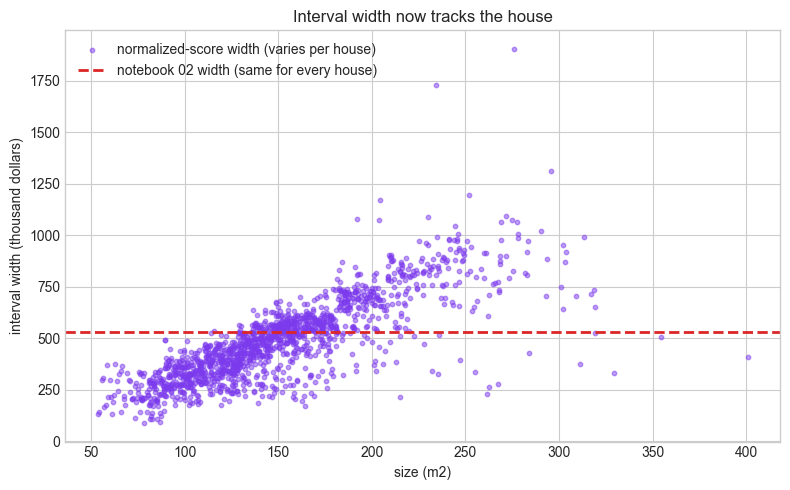

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test[:, 0], hi_norm - lo_norm, s=10, alpha=0.5, color=PURPLE,
           label="normalized-score width (varies per house)")
ax.axhline(2 * q_const, color=RED, linestyle="--", linewidth=2,
           label="notebook 02 width (same for every house)")
ax.set_title("Interval width now tracks the house")
ax.set_xlabel("size (m2)")
ax.set_ylabel("interval width (thousand dollars)")
ax.legend()
plt.tight_layout()
plt.show()

This is what the desk asked for: the purple cloud climbs with size, crossing the old
one-size-fits-all width (red dashed line) at roughly the 150 m2 mark. Homes to the left
of the crossing now get narrower, more competitive offers than notebook 02 gave them;
homes to the right get wider, more honest ones. The vertical spread of purple at any
fixed size is not noise — the difficulty model also reacts to age, distance and
condition, so two 150 m2 homes can legitimately get different widths. What this plot
does not show is coverage: a width that *tracks* difficulty is not yet proof that it
tracks it by the right amount, which is why the slice table above, not this scatter, is
the audit that counts.

## 5. Repair 2: conformalized quantile regression (CQR)

Repair 1 built the band from two estimates — a center $\hat{\mu}(x)$ and a scale
$\hat{\sigma}(x)$ — and we just watched the scale come up 23% short exactly where the
training data thins out. But why estimate center and scale separately, and hope neither
quietly fails, when a model can learn the band edges directly? **Quantile
regression** trains a regressor to predict not the average price but a chosen percentile
of price given the features — swap the squared-error loss for the tilted absolute-error
loss (the **pinball loss**) and everything else about model fitting stays the same. Fit
one model for the 5th percentile and one for the 95th, and their gap *is* a candidate 90%
band: asymmetric if the noise is skewed, wide where the market is wild, no separate scale
model needed.

The trap — and we will commit it live before fixing it — is to stop there and ship the
raw band. A quantile regressor's output is an *opinion* about the 5th and 95th
percentiles, learned from finite data with a loss function; nothing enforces that 90% of
fresh listings actually land between the two curves. Let us measure that opinion's actual
hit rate.

In [9]:
# Two quantile models: same features, same algorithm, different target percentile.
gb_lo = GradientBoostingRegressor(loss="quantile", alpha=alpha / 2, random_state=RANDOM_SEED)
gb_hi = GradientBoostingRegressor(loss="quantile", alpha=1 - alpha / 2, random_state=RANDOM_SEED)
gb_lo.fit(X_train, y_train)   # aims at the 5th percentile of price given features
gb_hi.fit(X_train, y_train)   # aims at the 95th

raw_lo_test = gb_lo.predict(X_test)
raw_hi_test = gb_hi.predict(X_test)
raw_covered = (y_test >= raw_lo_test) & (y_test <= raw_hi_test)

print("raw quantile-regression band, no conformal step:")
print(f"  test coverage: {raw_covered.mean():.3f} (we asked the models for 90%)")
print(f"  average width: {np.mean(raw_hi_test - raw_lo_test):.0f} thousand dollars")

raw quantile-regression band, no conformal step:
  test coverage: 0.879 (we asked the models for 90%)
  average width: 477 thousand dollars


There is the committed mistake, measured: the raw band covers 0.879, not the 0.90 we
asked the loss functions for — on 1,500 listings that shortfall is real, not noise
(two standard errors is ±0.015). The models' opinion of their own 5th-to-95th range is
slightly overconfident, which is the default failure mode of flexible models fit by any
loss. Note what 0.879 does not mean: it does not mean quantile regression is a bad idea —
the *shape* of this band is excellent, as we are about to see. It means an uncalibrated
band carries no guarantee, and whether it lands at 0.87 or 0.79 on the next dataset is
entirely up to luck and hyperparameters.

The conformal fix scores each calibration listing by *how far outside the claimed band*
the true price landed — positive dollars if outside, negative if safely inside:

$$s(x, y) = \max\big(\hat{q}_{lo}(x) - y,\; y - \hat{q}_{hi}(x)\big)$$

where $\hat{q}_{lo}(x)$ and $\hat{q}_{hi}(x)$ are the two quantile models' predictions
and $y$ is the true price. The corrected quantile of these scores, `q_hat`, is the
calibrated verdict on the raw band, and the final interval pushes both edges out by it:
$[\hat{q}_{lo}(x) - \hat{q},\; \hat{q}_{hi}(x) + \hat{q}]$. This is conformalized
quantile regression — CQR (Romano et al. 2019).

In [10]:
raw_lo_cal = gb_lo.predict(X_calib)
raw_hi_cal = gb_hi.predict(X_calib)

# How far OUTSIDE the claimed band did the truth land? Negative = inside.
scores_cqr = np.maximum(raw_lo_cal - y_calib, y_calib - raw_hi_cal)
q_cqr = corrected_quantile(scores_cqr, alpha)

lo_cqr = raw_lo_test - q_cqr
hi_cqr = raw_hi_test + q_cqr
covered_cqr = (y_test >= lo_cqr) & (y_test <= hi_cqr)

print(f"share of calibration listings already inside the raw band: {(scores_cqr < 0).mean():.3f}")
print(f"q_hat on CQR scores: {q_cqr:+.1f} thousand dollars (positive -> push both edges out)")
print(f"overall test coverage: {covered_cqr.mean():.3f}")
slice_report(lo_cqr, hi_cqr).round(3)

share of calibration listings already inside the raw band: 0.881
q_hat on CQR scores: +9.1 thousand dollars (positive -> push both edges out)
overall test coverage: 0.900


,listings,coverage,avg_width
size_bin,,,
small (<100 m2),217,0.903,275.876
mid (100-200 m2),1049,0.904,465.497
large (>200 m2),234,0.880,834.799


The calibration set found 88.1% of listings inside the raw band — short of 90%, agreeing
with what the test set told us — so `q_hat` came out positive, +9.1, and each edge moves
out by USD 9.1k. A modest correction (about 2% of the average band width), but it is the
difference between an opinion and a guarantee: coverage lands at 0.900 on the nose, and
the slices read 0.903 / 0.904 / 0.880 — the large-home bin is now within two standard
errors of target, the flattest profile we have seen.

One more subtlety: the correction is honest in both directions. Had the quantile models
been too *cautious* — raw band covering 94%, say — the scores would be mostly comfortably
negative, `q_hat` would come out negative, and the conformal step would *shrink* the band
symmetrically until it earned exactly its 90%. CQR does not just rescue overconfident
models; it also claws back width from timid ones. The guarantee machinery is a
thermostat, not a safety margin.

## 6. Bake-off

Three methods, one guarantee. A fair comparison reports three things side by side —
coverage (is the promise kept), average width (how much hedging it costs), and the slice
profile (where the width goes) — because any one of them alone can crown the wrong winner
(field guide §12: coverage alone is not an evaluation, and neither is average width).

In [11]:
methods = {
    "constant width (notebook 02)": (lo_const, hi_const),
    "normalized residuals": (lo_norm, hi_norm),
    "CQR": (lo_cqr, hi_cqr),
}

rows = []
for name, (lo, hi) in methods.items():
    per_bin = slice_report(lo, hi)["coverage"]
    rows.append({
        "method": name,
        "coverage": ((y_test >= lo) & (y_test <= hi)).mean(),
        "avg_width": np.mean(hi - lo),
        **{f"cov {b}": c for b, c in per_bin.items()},
    })

bakeoff = pd.DataFrame(rows).set_index("method")
bakeoff.round(3)

,coverage,avg_width,cov small (<100 m2),cov mid (100-200 m2),cov large (>200 m2)
method,,,,,
constant width (notebook 02),0.903,529.456,0.995,0.929,0.701
normalized residuals,0.897,488.393,0.917,0.909,0.825
CQR,0.900,495.676,0.903,0.904,0.880


The `coverage` column is the least interesting one in the table: 0.903, 0.897, 0.900 —
all three within noise of 0.90, exactly as the theorem promised for any score. The
`avg_width` column holds a small surprise: the adaptive methods are not just flatter but
slightly *cheaper* on average (488 and 496 against 529). That is not a law — adaptive
bands can come out a touch wider on other data — the honest reading is that average width
is roughly a tie, and the real difference lives in the slice columns. Constant width buys
its 0.995 on small homes by dumping USD 529k bands on everyone; the adaptive methods take
width away from the flats (where it covered nothing that needed covering) and spend it on
the villas (0.701 rising to 0.825 and 0.880). The win is *where* the width goes, not how
much of it there is.

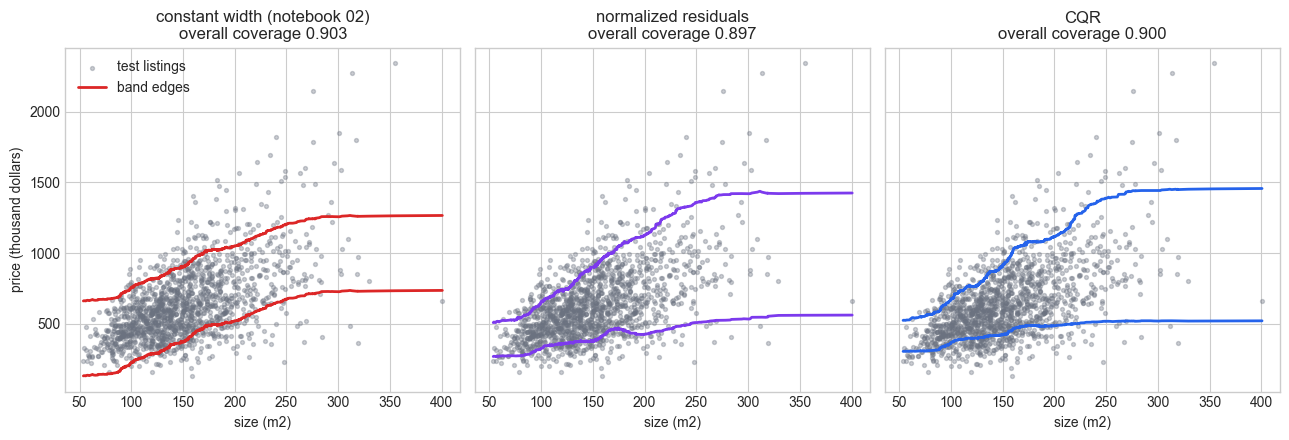

In [12]:
bands = [
    ("constant width (notebook 02)", lo_const, hi_const, RED),
    ("normalized residuals", lo_norm, hi_norm, PURPLE),
    ("CQR", lo_cqr, hi_cqr, BLUE),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, (name, lo, hi, color) in zip(axes, bands):
    ax.scatter(X_test[:, 0], y_test, s=8, alpha=0.35, color=GRAY, label="test listings")
    ax.plot(size_sorted, smooth_by_size(lo), color=color, linewidth=2, label="band edges")
    ax.plot(size_sorted, smooth_by_size(hi), color=color, linewidth=2)
    cov = ((y_test >= lo) & (y_test <= hi)).mean()
    ax.set_title(f"{name}\noverall coverage {cov:.3f}")
    ax.set_xlabel("size (m2)")
axes[0].set_ylabel("price (thousand dollars)")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

Same gray scatter three times, three very different bands, three statistically identical
coverage numbers. The red constant band is a rigid pipe laid over a funnel. The purple and
blue bands hug the ribbon on the left and open with the funnel on the right; look closely
above 250 m2 and the blue CQR band opens slightly wider than the purple one — that extra
mouth is precisely where normalized residuals left the villas at 0.825 and CQR reached
0.880. With 3,000 training listings and a stable boosted model the two repairs are
otherwise hard to tell apart, which matches Tibshirani's remark in the lecture notes:
on large, well-behaved data CQR adds little over studentized residuals, and normalized
scores stay popular because they only need off-the-shelf regressors fit in sequence.
CQR's edge shows up when the noise is skewed, when the tails misbehave, or — as with our
villas — when a stacked-on scale model goes wrong in a thin slice of the market: it
learns the quantiles a band is actually made of, rather than assembling them from two
point estimates and hoping both hold up where data is scarce.

## 7. Which repair when

| Situation | Reach for | Why |
|---|---|---|
| Errors look the same size everywhere (plain symmetric noise) | Constant width (notebook 02) | Adaptivity has nothing to adapt to; the extra models add moving parts and a little variance for no gain |
| Error spread visibly depends on the features (fan-shaped residual plot) | Normalized residuals | Two off-the-shelf regressors fit in sequence; one unitless quantile; easiest retrofit to an existing pipeline |
| Skewed targets, asymmetric risk, fat tails — or you already run quantile models | CQR | Learns each band edge directly, so the band can be asymmetric; targets the tail quantiles coverage is actually made of |
| A named slice needs its own guarantee (contract, regulator, support queue) | Group-conditional calibration | Calibrate each group separately, one `q_hat` per group, the same at-least-90% guarantee per named group — notebook 04's Mondrian fix, at the cost of needing enough calibration data per group |

The last row is the teaser: when "close to 90% on villas" is not good enough — when a
contract *names* the slice — you stop shaping scores and start splitting calibration
sets. That is a different tool with a different cost, and notebook 04 already showed it
working for classes; the regression version is identical in spirit.

## 8. Common mistakes to avoid

1. **Judging adaptivity by average width.** A fixed-width band can match an adaptive one
   on average width while undercovering every hard slice (our bake-off: 529 vs 488 vs 496
   — nearly a tie that hides a 0.701-vs-0.880 gap on villas). Always read the slice
   columns before the width column (field guide §12).
2. **Shipping raw quantile regression without the conformal step.** The raw band is an
   opinion; ours covered 0.879 when it claimed 90%, and nothing bounds how much worse
   another dataset or hyperparameter choice makes it. The conformal correction costs one
   quantile computation and turns the opinion into a guarantee.
3. **Fitting the difficulty model on calibration data.** $\hat{\sigma}$ is part of the
   score. If it has seen the calibration labels, calibration scores are no longer
   exchangeable with a fresh listing's score and the guarantee silently breaks —
   the same leakage field guide §2 warns about, one level up.
4. **Checking coverage by slice only after shipping.** The slice table in section 2 used
   nothing but held-out data we already had; the desk should never have been the ones to
   find the 0.701. Print the table for every slice a contract or a support queue cares
   about, before deployment (field guide §3).
5. **"Fixing" a wide villa band by clipping it.** The wide band is the honest answer on a
   hard house (field guide §7). Cap it and you reinstate the false confidence this whole
   series exists to remove; route the widest offers to a human reviewer instead.

## 9. What to say in the business review

**Strong version:**

> "We replaced the flat ±USD 265k band with one that breathes with the house. On 1,500
> held-out listings the band now averages USD 276k wide on small flats and USD 835k on large
> villas, overall coverage holds at 90.0%, and the worst size segment improved from 70%
> coverage to 88%. Same guarantee, same model, same data — the width just moved to where
> the pricing risk actually lives. Villa offers with the widest bands go to manual review."

**Weak version:**

> "The new intervals are 90% accurate for every type of home, thanks to an adaptive
> nonconformity score with conformalized quantile regression."

The weak version claims per-type coverage that no distribution-free method can promise —
section 3's impossibility theorem, restated as marketing — and hides the one number the
desk will feel (how wide the band is on the homes they price daily) behind jargon. The
strong version quotes the slice table, admits the guarantee is marginal, and says what
happens operationally when the band is wide.

### The one-line summary

Notebook 02's interval was not wrong, it was blunt: one yardstick, priced in raw dollars,
for a market where the honest band is three times wider on a villa than on a flat
(USD 835k against USD 276k in the bake-off). Changing the yardstick — errors in units
of local difficulty, or distance outside a learned quantile band — changed nothing about
the guarantee and everything about who gets a useful offer. Coverage was never the thing
we had to earn; shape was.

The guarantee never moves; the score decides where the width goes.